---
date: "2026-07-19"
date-modified: last-modified
format:
  html:
    toc: true
---

# Order Statistics

In probability theory and statistical inference, **order statistics** represent the sample values of a random vector sorted in non-decreasing order from the smallest to the largest. Even when the original sample consists of strictly [independent random variables](independence-of-rvs.ipynb) and identically distributed  observations, sorting creates structural **dependence** among the ordered values.

Order statistics provide the mathematical foundations for non-parametric statistics, sample quantiles, extreme value theory, and ranking problems. Through the exact analytical derivation of their distributions, order statistics reveal deep connections with the **[Beta Distribution](beta-distribution.ipynb)** and the **[Gamma Distribution](gamma-function-and-distribution.ipynb)**.

---

## Overview of Key Topics

1. **Definition and Ranking:** Formal definition of order statistics $X_{(1)} \le \dots \le X_{(n)}$, sample quantiles, and the origins of ordering dependence.
2. **General Exact CDF and PDF Derivations:** Step-by-step rigorous proofs of the cumulative distribution function via **[Binomial sums](bernoulli-and-binomial-distributions.ipynb)**, and the probability density function via the infinitesimal bucket heuristic and combinatorial partitioning.
3. **Uniform Order Statistics & The Beta Connection:** Proof that the order statistics of standard uniform distributions follow exact Beta distributions $\text{Beta}(j, n-j+1)$, with explicit expected value calculations and symmetry interpretations.

## 1\. Order Statistics and Dependence

When we collect random samples from a population, our raw observations arrive in arbitrary chronological order. Sorting them ranks the data by magnitude.

::: {#def-order-statistics}
## Order Statistics
Let $X_1, X_2, \dots, X_n$ be a sample of $n$ independent and identically distributed  random variables defined on a common probability space, each with cumulative distribution function  $F(x)$.

The **order statistics** of the sample, denoted by parenthetical subscripts, are the random variables obtained by sorting $X_1, \dots, X_n$ in non-decreasing order:
$$
X_{(1)} \le X_{(2)} \le \dots \le X_{(n)}
$$
Specifically:
- $X_{(1)} = \min(X_1, X_2, \dots, X_n)$ is the **sample minimum** (the $1$st order statistic).
- $X_{(n)} = \max(X_1, X_2, \dots, X_n)$ is the **sample maximum** (the $n$-th order statistic).
- $X_{(j)}$ is the $j$-th smallest value in the sample (the $j$-th order statistic).
:::

Order statistics directly define all standard sample quantiles.

::: {#def-sample-quantiles}
## Sample Quantiles and Median
For an ordered sample of size $n$, empirical sample quantiles are defined by specific order statistic indices:
- **Sample Median:** The middle observation dividing the sample in half:
$$
\text{Median} = \begin{cases}
X_{\left(\frac{n+1}{2}\right)} & \text{if } n \text{ is odd} \\
\frac{1}{2} \left( X_{(n/2)} + X_{(n/2 + 1)} \right) & \text{if } n \text{ is even}
\end{cases}
$$
- **Sample Range:** The difference between extreme order statistics: $R = X_{(n)} - X_{(1)}$.
:::

::: {.callout-warning}
## Why Order Statistics Are Difficult: Induced Dependence
A critical conceptual pitfall is assuming that because the raw sample $X_1, \dots, X_n$ are independent, the order statistics $X_{(1)}, \dots, X_{(n)}$ are independent. **They are strongly dependent!**

Because of the rigid inequality constraints $X_{(1)} \le X_{(2)} \le \dots \le X_{(n)}$, knowing the value of one order statistic immediately constrains the support of all others. For instance, if you learn that the maximum $X_{(n)} = 4.2$, you instantly know with $100\%$ certainty that every other order statistic must satisfy $X_{(1)}, \dots, X_{(n-1)} \le 4.2$. Therefore, their joint probability distributions cannot factor into independent products.
:::

## 2\. Cumulative Distribution Function and Probability Density Function of $X_{(j)}$

We now derive the exact cumulative distribution function (CDF) and probability density function (PDF) for the $j$-th order statistic $X_{(j)}$ of a continuous random sample.

::: {#thm-order-stat-cdf-pdf}
## CDF and PDF of the $j$-th Order Statistic
Let $X_1, X_2, \dots, X_n \stackrel{\text{i.i.d.}}{\sim} F$ be a sample of continuous random variables with cumulative distribution function $F(x)$ and probability density function $f(x)$. For any index $j \in \{1, 2, \dots, n\}$:

1. The **cumulative distribution function** $F_{X_{(j)}}(x) = P(X_{(j)} \le x)$ is given by:
$$
F_{X_{(j)}}(x) = \sum_{k=j}^n \binom{n}{k} [F(x)]^k [1 - F(x)]^{n-k}
$$
2. The **probability density function** $f_{X_{(j)}}(x)$ is given by:
$$
f_{X_{(j)}}(x) = n \binom{n-1}{j-1} [F(x)]^{j-1} [1 - F(x)]^{n-j} f(x)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Order Statistic CDF and PDF
**Part 1: Derivation of the Cumulative Distribution Function $F_{X_{(j)}}(x)$**

By definition, the event $\{X_{(j)} \le x\}$ (the $j$-th smallest observation is less than or equal to $x$) occurs if and only if **at least $j$ out of the $n$ total sample observations are less than or equal to $x$**.

Let us define $n$ independent Bernoulli indicator random variables:
$$
I_i = \begin{cases}
1 & \text{if } X_i \le x \\
0 & \text{if } X_i > x
\end{cases}, \quad \text{for } i = 1, 2, \dots, n
$$

Because the sample $X_1, \dots, X_n$ is i.i.d., the success probability $p$ for each indicator at a fixed threshold $x$ is:
$$
p = P(I_i = 1) = P(X_i \le x) = F(x)
$$
And the failure probability is $1 - p = P(X_i > x) = 1 - F(x)$.

Let $N_x = \sum_{i=1}^n I_i$ denote the total count of sample items landing in $(-\infty, x]$. Since $N_x$ is the sum of $n$ independent Bernoulli trials, $N_x$ follows exactly a **[Binomial Distribution](bernoulli-and-binomial-distributions.ipynb)** with parameters $n$ and success probability $p = F(x)$:
$$
N_x \sim \text{Bin}(n, F(x))
$$

Therefore, the exact probability that $X_{(j)} \le x$ is the Binomial tail summation from $k=j$ successes up to $n$ successes:
$$
\begin{aligned}
F_{X_{(j)}}(x) &= P(X_{(j)} \le x) \\
&= P(N_x \ge j) \\
&= \sum_{k=j}^n P(N_x = k) \\
&= \sum_{k=j}^n \binom{n}{k} [F(x)]^k [1 - F(x)]^{n-k}
\end{aligned}
$$
This completes the CDF derivation.

**Part 2: Derivation of the Probability Density Function $f_{X_{(j)}}(x)$**

We present two distinct, mathematically rigorous derivations of the PDF: the intuitive infinitesimal heuristic argument (as structured in classical probability notes), and the analytical differentiation of the Binomial CDF sum.

**Method A: The Infinitesimal Bucket Story (Combinatorial Partitioning)**
To find the probability element $f_{X_{(j)}}(x) dx = P(x < X_{(j)} \le x + dx)$ for an infinitesimal width $dx \to 0$, we analyze what must happen to the $n$ sample observations for the $j$-th sorted value to land precisely inside the tiny interval $(x, x + dx)$:

1. **The $j$-th observation itself:** Exactly $1$ specific sample observation out of the $n$ total must fall inside the infinitesimal bucket $(x, x + dx)$. The probability of any single variable landing inside $(x, x + dx)$ is $f(x) dx$. There are $\binom{n}{1} = n$ distinct choices for *which* of the $n$ sample items lands inside this infinitesimal bucket.
2. **The observations smaller than $x$:** Among the remaining $n-1$ sample variables, exactly $j-1$ variables must fall entirely to the left of the bucket in the interval $(-\infty, x]$. Each of these $j-1$ independent variables falls in $(-\infty, x]$ with probability $F(x)$.
3. **The observations larger than $x$:** The remaining $(n-1) - (j-1) = n-j$ variables must fall entirely to the right of the bucket in the interval $(x + dx, \infty)$. Each of these $n-j$ independent variables lands in $(x + dx, \infty)$ with probability $1 - F(x)$ (since $dx \to 0$).
4. **Combinatorial choices for the partition:** Once we have chosen which single variable lands in $(x, x+dx)$ (giving factor $n$), the number of ways to choose *which* $j-1$ variables land to the left out of the remaining $n-1$ variables is given by the binomial coefficient:
$$
\binom{n-1}{j-1}
$$

Multiplying all these independent combinatorial and probabilistic requirements together gives the infinitesimal probability element:
$$
f_{X_{(j)}}(x) dx = n \times \binom{n-1}{j-1} \times [F(x)]^{j-1} \times [1 - F(x)]^{n-j} \times f(x) dx
$$

Dividing both sides by $dx$ yields the exact probability density formula:
$$
f_{X_{(j)}}(x) = n \binom{n-1}{j-1} [F(x)]^{j-1} [1 - F(x)]^{n-j} f(x)
$$

**Method B: Analytical Differentiation of the CDF Sum**
We differentiate $F_{X_{(j)}}(x) = \sum_{k=j}^n \binom{n}{k} [F(x)]^k [1 - F(x)]^{n-k}$ with respect to $x$ using the product rule:
$$
\begin{aligned}
f_{X_{(j)}}(x) &= \frac{d}{dx} F_{X_{(j)}}(x) \\
&= \sum_{k=j}^n \binom{n}{k} \left( k [F(x)]^{k-1} f(x) [1 - F(x)]^{n-k} - (n-k) [F(x)]^k [1 - F(x)]^{n-k-1} f(x) \right)
\end{aligned}
$$

Notice the algebraic identities for terms inside the sum:
$$
\binom{n}{k} k = \frac{n!}{(k-1)!(n-k)!} = n \binom{n-1}{k-1}, \quad \binom{n}{k} (n-k) = \frac{n!}{k!(n-k-1)!} = n \binom{n-1}{k}
$$

Substituting these identities and factoring out $n f(x)$:
$$
f_{X_{(j)}}(x) = n f(x) \left[ \sum_{k=j}^n \binom{n-1}{k-1} [F(x)]^{k-1} [1 - F(x)]^{n-k} - \sum_{k=j}^{n-1} \binom{n-1}{k} [F(x)]^k [1 - F(x)]^{n-k-1} \right]
$$

Let us shift the index on the second summation by setting $m = k+1 \implies k = m-1$. As $k$ runs from $j$ up to $n-1$, $m$ runs from $j+1$ up to $n$:
$$
\sum_{k=j}^{n-1} \binom{n-1}{k} [F(x)]^k [1 - F(x)]^{n-k-1} = \sum_{m=j+1}^n \binom{n-1}{m-1} [F(x)]^{m-1} [1 - F(x)]^{n-m}
$$

Notice that every single term in the second sum exactly cancels out every term in the first sum from $k = j+1$ to $n$! This perfect telescoping cancellation leaves only the single leading term at $k = j$ from the first sum:
$$
f_{X_{(j)}}(x) = n f(x) \left[ \binom{n-1}{j-1} [F(x)]^{j-1} [1 - F(x)]^{n-j} \right] = n \binom{n-1}{j-1} [F(x)]^{j-1} [1 - F(x)]^{n-j} f(x)
$$
Both methods establish the exact probability density function. $\blacksquare$
:::

::: {.callout-note}
## Intuition: The Infinitesimal Bucket Story
The formula $f_{X_{(j)}}(x) = n \binom{n-1}{j-1} [F(x)]^{j-1} [1 - F(x)]^{n-j} f(x)$ has an immediate, transparent narrative interpretation:
To make $X_{(j)}$ equal $x$, pick which of the $n$ variables lands right at $x$ ($n$ choices with density $f(x)$), then out of the remaining $n-1$ variables choose which $j-1$ variables lie to the left ($\binom{n-1}{j-1}$ ways, each with probability $F(x)$), leaving the remaining $n-j$ variables to lie to the right (each with probability $1 - F(x)$).
:::

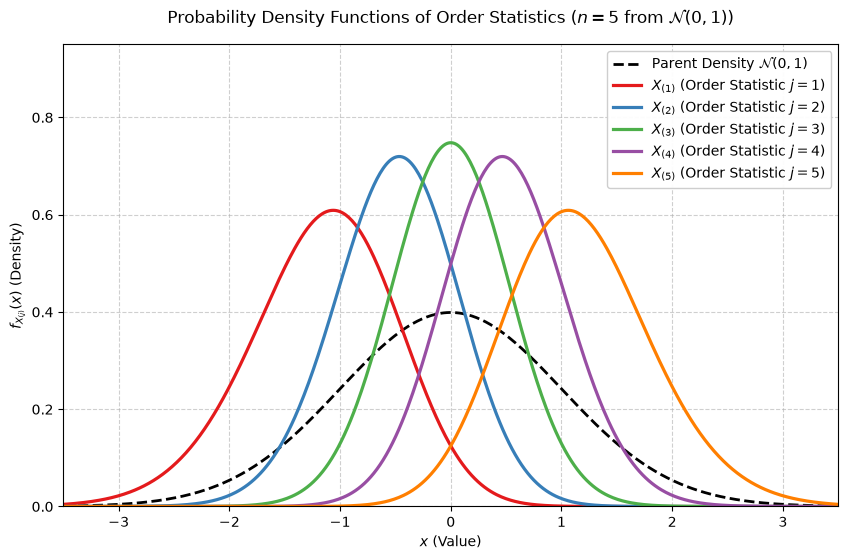

In [1]:
# Visualizing all order statistics PDFs for a sample of n=5 from Standard Normal N(0,1)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import gamma as scipy_gamma

x_grid = np.linspace(-3.5, 3.5, 500)
n_sample = 5

# Compute standard normal CDF and PDF
Phi_x = norm.cdf(x_grid)
phi_x = norm.pdf(x_grid)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot parent normal density for reference
ax.plot(x_grid, phi_x, color='black', lw=2.0, linestyle='--', label=r'Parent Density $\mathcal{N}(0, 1)$')

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

# Plot each order statistic j = 1 to 5
for j in range(1, n_sample + 1):
    # Binomial coefficient n * (n-1 C j-1)
    coeff = n_sample * (scipy_gamma(n_sample) / (scipy_gamma(j) * scipy_gamma(n_sample - j + 1)))
    
    # Compute order statistic PDF
    pdf_j = coeff * (Phi_x**(j - 1)) * ((1 - Phi_x)**(n_sample - j)) * phi_x
    
    ax.plot(x_grid, pdf_j, lw=2.3, color=colors[j-1], label=f'$X_{{({j})}}$ (Order Statistic $j={j}$)')

ax.set_title(r'Probability Density Functions of Order Statistics ($n=' + str(n_sample) + r'$ from $\mathcal{N}(0, 1)$)', pad=15)
ax.set_xlabel('$x$ (Value)')
ax.set_ylabel('$f_{X_{(j)}}(x)$ (Density)')
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(0, 0.95)
ax.legend(loc='upper right', frameon=True, framealpha=0.95)
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 3\. Uniform Order Statistics and the Beta Distribution

When the underlying parent distribution is the standard uniform distribution, the order statistics simplify into one of the most celebrated exact connections in probability: **Uniform order statistics are exactly Beta-distributed random variables**.

::: {#thm-uniform-order-statistics}
## Uniform Order Statistics as Beta Random Variables
Let $U_1, U_2, \dots, U_n \stackrel{\text{i.i.d.}}{\sim} \text{Unif}(0, 1)$ be independent standard uniform random variables on the unit interval. For any rank $j \in \{1, 2, \dots, n\}$, the $j$-th order statistic $U_{(j)}$ follows a **Beta distribution** with shape parameters $a = j$ and $b = n - j + 1$:
$$
U_{(j)} \sim \text{Beta}(j, n - j + 1)
$$
Its exact probability density function on $0 < x < 1$ is:
$$
f_{U_{(j)}}(x) = \frac{\Gamma(n+1)}{\Gamma(j)\Gamma(n-j+1)} x^{j-1} (1-x)^{n-j}
$$
And its expected value is:
$$
E[U_{(j)}] = \frac{j}{n+1}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Uniform Order Statistics as Beta Random Variables
For a standard uniform random variable $U_i \sim \text{Unif}(0, 1)$, over the domain $0 < x < 1$ the cumulative distribution function is exactly linear ($F(x) = x$), and the probability density function is constant ($f(x) = 1$).

We substitute $F(x) = x$ and $f(x) = 1$ directly into our general order statistic PDF formula from Theorem 3:
$$
\begin{aligned}
f_{U_{(j)}}(x) &= n \binom{n-1}{j-1} [F(x)]^{j-1} [1 - F(x)]^{n-j} f(x) \\
&= n \binom{n-1}{j-1} x^{j-1} (1-x)^{n-j} \cdot 1 \\
&= n \frac{(n-1)!}{(j-1)!(n-j)!} x^{j-1} (1-x)^{n-j} \\
&= \frac{n!}{(j-1)!(n-j)!} x^{j-1} (1-x)^{n-j}
\end{aligned}
$$

Using the factorial Gamma relation $\Gamma(m) = (m-1)!$, we write the coefficient in terms of Gamma functions:
$$
\frac{n!}{(j-1)!(n-j)!} = \frac{\Gamma(n+1)}{\Gamma(j)\Gamma(n-j+1)} = \frac{1}{B(j, n-j+1)}
$$
where $B(a, b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)}$ is the Beta function.

Therefore, for $0 < x < 1$, the density of $U_{(j)}$ is:
$$
f_{U_{(j)}}(x) = \frac{1}{B(j, n-j+1)} x^{j-1} (1-x)^{(n-j+1)-1}
$$
This matches identically the definition of a **Beta distribution** with first shape parameter $a = j$ and second shape parameter $b = n - j + 1$:
$$
U_{(j)} \sim \text{Beta}(j, n - j + 1)
$$

To compute the expected value $E[U_{(j)}]$, we apply the standard formula for the mean of a $\text{Beta}(a, b)$ random variable, $E[W] = \frac{a}{a+b}$:
$$
\begin{aligned}
E[U_{(j)}] &= \frac{a}{a + b} \\
&= \frac{j}{j + (n - j + 1)} \\
&= \frac{j}{n+1}
\end{aligned}
$$

As special cases of immediate interest:
- The sample minimum $U_{(1)} \sim \text{Beta}(1, n)$ has expected value $E[U_{(1)}] = \frac{1}{n+1}$.
- The sample maximum $U_{(n)} \sim \text{Beta}(n, 1)$ has expected value $E[U_{(n)}] = \frac{n}{n+1}$.
- The median (for $n=2k+1$ odd) $U_{(k+1)} \sim \text{Beta}(k+1, k+1)$ has expected value $E[U_{(k+1)}] = \frac{k+1}{2k+2} = \frac{1}{2}$. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Uniform Partition of the Unit Interval
Why is the expected value of the $j$-th order statistic equal to $\frac{j}{n+1}$ rather than $\frac{j}{n}$?

Imagine dropping $n$ points randomly and uniformly across the unit interval $(0, 1)$. These $n$ ordered points $U_{(1)} < U_{(2)} < \dots < U_{(n)}$ divide the interval into exactly $n+1$ sub-intervals:
$$
(0, U_{(1)}), \; (U_{(1)}, U_{(2)}), \; \dots, \; (U_{(n-1)}, U_{(n)}), \; (U_{(n)}, 1)
$$
By complete symmetry, the $n+1$ segments created by $n$ uniformly distributed points must have the exact same expected length! Since their total combined length is $1$, each of the $n+1$ gaps has expected length $\frac{1}{n+1}$.

Because the $j$-th order statistic $U_{(j)}$ is precisely the accumulated length of the first $j$ consecutive sub-intervals, its expected position is $j \times \frac{1}{n+1} = \frac{j}{n+1}$.
:::

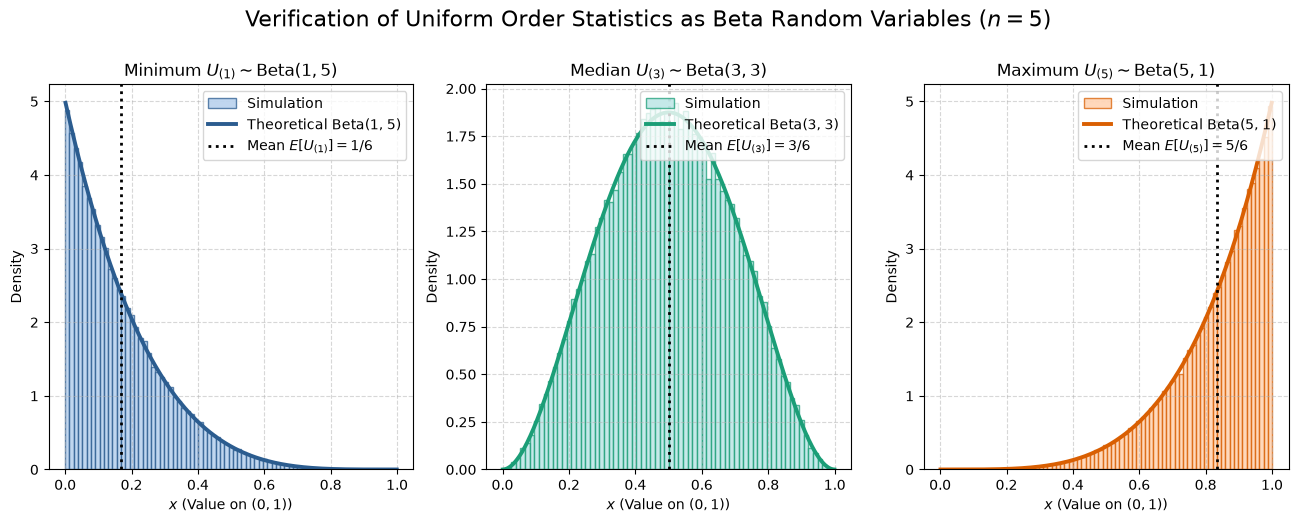

In [2]:
# Simulation verifying Uniform Order Statistics U_(j) ~ Beta(j, n-j+1)
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as scipy_gamma

np.random.seed(101)
N_sim = 100_000
n_pts = 5

# Generate N_sim independent samples of size n_pts from Unif(0, 1)
U_samples = np.random.uniform(0.0, 1.0, size=(N_sim, n_pts))

# Sort along axis 1 to obtain order statistics U_(1) <= U_(2) <= ... <= U_(5)
U_ordered = np.sort(U_samples, axis=1)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
u_grid = np.linspace(0.001, 0.999, 400)

# Check ranks j = 1 (Minimum), j = 3 (Median), j = 5 (Maximum)
ranks = [
    (1, '#2b5c8f', '#abc9ea', r'Minimum $U_{(1)} \sim \text{Beta}(1, 5)$'),
    (3, '#1b9e77', '#b2e2e2', r'Median $U_{(3)} \sim \text{Beta}(3, 3)$'),
    (5, '#d95f02', '#ffcba4', r'Maximum $U_{(5)} \sim \text{Beta}(5, 1)$')
]

for idx, (j, line_col, hist_col, title_str) in enumerate(ranks):
    # Empirical order statistic samples (0-indexed in python so j-1)
    sim_data = U_ordered[:, j - 1]
    
    # Theoretical Beta(j, n-j+1) PDF
    a_beta = j
    b_beta = n_pts - j + 1
    beta_pdf = (scipy_gamma(a_beta + b_beta) / (scipy_gamma(a_beta) * scipy_gamma(b_beta))) * \
               (u_grid**(a_beta - 1)) * ((1 - u_grid)**(b_beta - 1))
    
    axs[idx].hist(sim_data, bins=70, density=True, color=hist_col, edgecolor=line_col, alpha=0.75, label='Simulation')
    axs[idx].plot(u_grid, beta_pdf, color=line_col, lw=2.8, label=f'Theoretical Beta({a_beta}, {b_beta})')
    axs[idx].axvline(j / (n_pts + 1), color='black', linestyle=':', lw=2.0, label=f'Mean $E[U_{{({j})}}] = {j}/{n_pts+1}$')
    
    axs[idx].set_title(title_str)
    axs[idx].set_xlabel('$x$ (Value on $(0, 1)$)')
    axs[idx].set_ylabel('Density')
    axs[idx].legend(loc='upper right')
    axs[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle(f'Verification of Uniform Order Statistics as Beta Random Variables ($n={n_pts}$)', fontsize=16, y=1.03)
plt.show()

> **References & Acknowledgments:**
> Problems and derivations adapted from *Introduction to Probability* by Joseph K. Blitzstein and Jessica Hwang, and classical lecture notes on order statistics, sample quantiles, and Uniform-Beta distributions.